# Simulação Computacional: Sistemas Discretos e suas Propriedades

Neste experimento, aplicamos um sinal de entrada a três sistemas discretos distintos para investigar as suas propriedades fundamentais: memória, linearidade e invariância no tempo.

Reaproveitamos o pulso transitório (Tópico 5) como entrada $x[n]$ e avaliamos as seguintes saídas:
1. **Sistema LTI com Memória:** Filtro de média móvel de 3 pontos.
2. **Sistema Não-Linear:** Amplificador quadrático ($y[n] = x[n]^2$).
3. **Sistema Variante no Tempo:** Modulador temporal ($y[n] = n \cdot x[n]$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo acadêmico
sns.set_theme(
    context="paper", style="ticks", palette="colorblind", font="serif",
    rc={
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.6,
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
    },
)

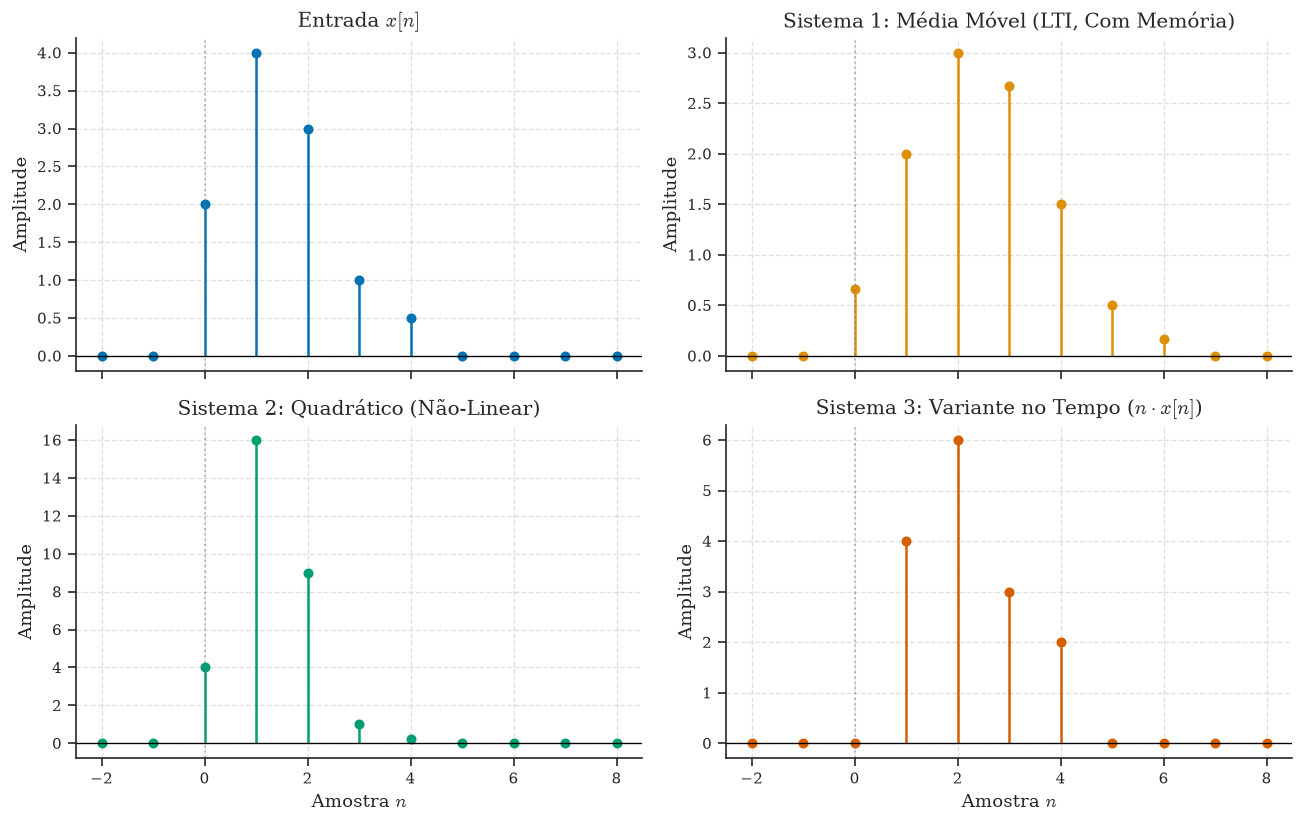

In [2]:
# 1. Vetor de tempo discreto
n = np.arange(-2, 9)

# 2. Sinal de Entrada: Pulso transitório
x = np.zeros_like(n, dtype=float)
valores = [2.0, 4.0, 3.0, 1.0, 0.5]
for i, val in enumerate(valores):
    x[n == i] = val

# 3. Implementação dos Sistemas

# Sistema 1: Média Móvel (LTI, Com Memória)
# y1[n] = (1/3) * (x[n] + x[n-1] + x[n-2])
y1 = np.zeros_like(x)
for i in range(len(n)):
    # Tratamento de borda simples para evitar índice negativo na simulação
    x_n = x[i]
    x_n_1 = x[i-1] if i-1 >= 0 else 0
    x_n_2 = x[i-2] if i-2 >= 0 else 0
    y1[i] = (x_n + x_n_1 + x_n_2) / 3.0

# Sistema 2: Quadrático (Não-Linear, Sem Memória)
# y2[n] = x[n]^2
y2 = x**2

# Sistema 3: Variante no Tempo (Linear, Sem Memória)
# y3[n] = n * x[n]
y3 = n * x

# 4. Configuração da Figura (Painel 2x2)
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
cores = sns.color_palette("colorblind")

sistemas = [
    (axes[0, 0], x, r"Entrada $x[n]$", cores[0]),
    (axes[0, 1], y1, r"Sistema 1: Média Móvel (LTI, Com Memória)", cores[1]),
    (axes[1, 0], y2, r"Sistema 2: Quadrático (Não-Linear)", cores[2]),
    (axes[1, 1], y3, r"Sistema 3: Variante no Tempo ($n \cdot x[n]$)", cores[3])
]

for ax, seq, titulo, cor in sistemas:
    markerline, stemlines, baseline = ax.stem(
        n, seq, linefmt="-", markerfmt="o", basefmt=" "
    )
    plt.setp(stemlines, color=cor, linewidth=1.5)
    plt.setp(markerline, color=cor, markersize=5)
    
    # Destacar eixos n=0 e amplitude=0
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
    
    ax.set_title(titulo)
    ax.set_ylabel("Amplitude")
    ax.set_xticks(np.arange(-2, 9, 2))

axes[1, 0].set_xlabel(r"Amostra $n$")
axes[1, 1].set_xlabel(r"Amostra $n$")

sns.despine(trim=False)
fig.tight_layout()

# Salvamento
os.makedirs(".", exist_ok=True)
fig.savefig("grafico_sistemas.png")
plt.show()